In [1]:
import nextnanopy as nn
import os
import matplotlib.pyplot as plt
import numpy as np
import sys


In [2]:
path_nextnanoprojects_tools = r"C:\Users\sp6497_a\nextnanopy_projects"

In [3]:
print(sys.path)
sys.path.append(path_nextnanoprojects_tools)
print(sys.path)
from nextnano_tools.helper_functions import build_output
from nextnano_tools.simstructs import SimOut, BandStructure, Eigenstate

['c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev\\python313.zip', 'c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev\\DLLs', 'c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev\\Lib', 'c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev', '', 'c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev\\Lib\\site-packages', 'c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev\\Lib\\site-packages\\win32', 'c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev\\Lib\\site-packages\\win32\\lib', 'c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev\\Lib\\site-packages\\Pythonwin']
['c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev\\python313.zip', 'c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev\\DLLs', 'c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev\\Lib', 'c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev', '', 'c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev\\Lib\\site-packages', 'c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev\\Lib\\site-packages\\win32', 'c:\\Users\\sp6497_a\\min

In [4]:
bias = r'bias_00000'
quantum_region = r'Quantum\quantum_region'
quantum_band = r'kp8'
quantum_band_interactions = r'kp8_kp8'
# quantum_band = r'Gamma'
# quantum_band_interactions = r'Gamma_Gamma'

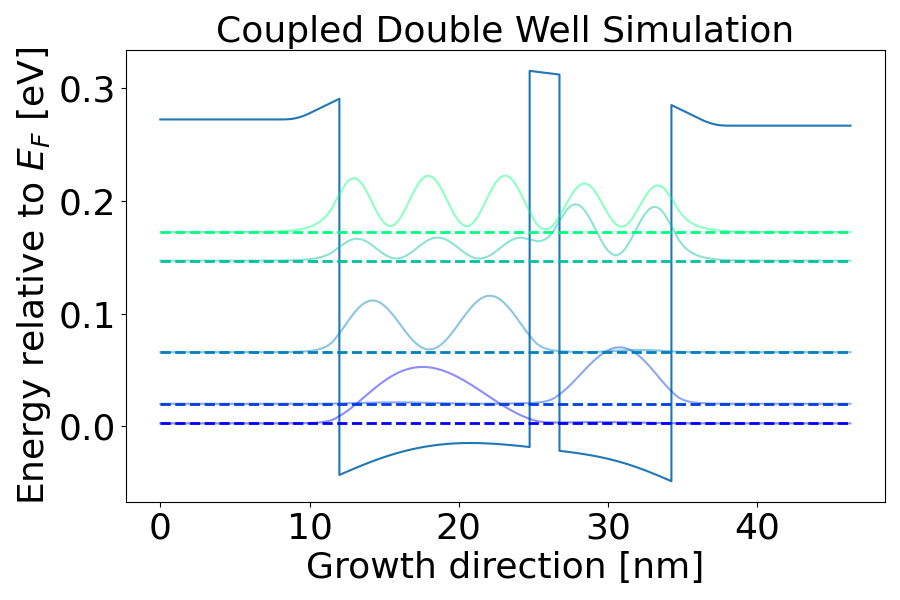


Intersubband transition energies — CB
-----------------------------------------------------
 i → j | ΔE (eV)
-----------------------------------------------------
  1 →  2 | -0.0174
  4 →  5 | -0.0254
  2 →  3 | -0.0457
  1 →  3 | -0.0631
  3 →  4 | -0.0811
  3 →  5 | -0.1065
  2 →  4 | -0.1268
  1 →  4 | -0.1442
  2 →  5 | -0.1522
  1 →  5 | -0.1696
-----------------------------------------------------



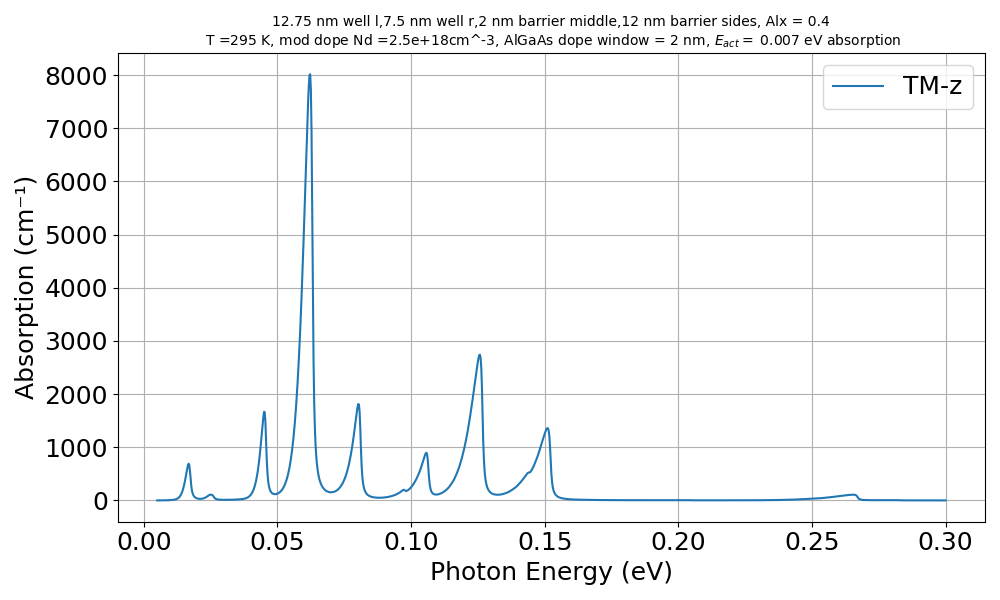

<Axes: title={'center': '12.75 nm well l,7.5 nm well r,2 nm barrier middle,12 nm barrier sides, Alx = 0.4\n T =295 K, mod dope Nd =2.5e+18cm^-3, AlGaAs dope window = 2 nm, $E_{act}=$ 0.007 eV absorption'}, xlabel='Photon Energy (eV)', ylabel='Absorption (cm⁻¹)'>

In [ ]:
%matplotlib widget
parent_dir = r"C:\Users\sp6497_a\OneDrive - Princeton University\nextnano_outs\Output\AlGaAs_GaAs_DW_absorption_len_specific_check(1)"
VB_cutoff = -1
simoutidk = build_output(parent_dir,quantum_region,bias,14,quantum_band = quantum_band, quantum_band_interactions = quantum_band_interactions, VB_cutoff=VB_cutoff,model='kp')
simoutidk.bands['CB'].sort_subbands(decreasing=False)
simoutidk.bands['CB'].remove_subband(index=7)
simoutidk.bands['CB'].remove_subband(index=6)
# simout.bands['CB'].

barrier_sides = simoutidk.variables['w_barrier']
w_middle_barrier = simoutidk.variables['w_middle_barrier']
w_well_l = simoutidk.variables['w_well_l']
w_well_r = simoutidk.variables['w_well_r']
temp = simoutidk.variables['temp']
# temp = 295


mod_dop_cc = simoutidk.variables['impurity_conc_cc']
AlGaAs_dop_window = simoutidk.variables['delta_donor_w']
Al_x = simoutidk.variables['Al_alloy']
act_E_AlaAs = simoutidk.variables['activation_E_AlAs']
# act_E_AlaAs =-100.0

font_base = 26

base_title = str(w_well_l) +' nm well l,' + str(w_well_r) + ' nm well r,' + str(w_middle_barrier) + ' nm barrier middle,' + str(barrier_sides) + ' nm barrier sides, Alx = ' + str(Al_x) + '\n T =' + str(temp) + ' K, mod dope Nd =' + str(mod_dop_cc) + 'cm^-3, AlGaAs dope window = '+ str(AlGaAs_dop_window) + ' nm, $E_{act}=$ ' + str(act_E_AlaAs) + ' eV'
title_poster = 'Coupled Double Well Simulation'
poster_fig,poster_ax = plt.subplots(figsize=(9,6))
simoutidk.bands['CB'].plot_band(ax=poster_ax,title_diff=title_poster,normalize_y=False,fontsizetitle=font_base,show_legend=False,fontsizebase=font_base)
simoutidk.bands['CB'].calc_intersubband_transitions()
simoutidk.bands['CB'].display_intersubband_transitions(upward_only=True,sort_by_deltaE="descending")
simoutidk.optical_absorption.get_spectrum('TM-z').plot(show_grid=True,diff_title=base_title + ' absorption', fontsizetitle=font_base)

In [6]:
parent_dir = r'C:\Users\sp6497_a\nextnano_outs\Output\middle_7.5nm_well_hybridized(7)'
VB_cutoff = -1
simoutidk = build_output(parent_dir,quantum_region,quantum_band,quantum_band_interactions,bias,VB_cutoff,14)
simoutidk.bands['CB'].sort_subbands(decreasing=False)
simoutidk.bands['CB'].remove_subband(index=7)
simoutidk.bands['CB'].remove_subband(index=6)
# simout.bands['CB'].
simoutidk.bands['CB'].plot_band(title_diff='Schrodinger-Poisson well_l 12.75 nm well_r 7.5nm, barrier 2nm',normalize_y=False)
simoutidk.bands['CB'].calc_intersubband_transitions()
simoutidk.bands['CB'].display_intersubband_transitions(upward_only=True,sort_by_deltaE="descending")
simoutidk.optical_absorption.get_spectrum('TM-z').plot(show_grid=True,diff_title='ISB absorption T=100K')

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\sp6497_a\\nextnano_outs\\Output\\middle_7.5nm_well_hybridized(7)\\kp8\\bandedges.dat'